In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

In [2]:
# Load cleaned datasets

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

scheme = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [3]:
# Display first five rows

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [6]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [7]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [8]:
# Display dataset information

fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [9]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [10]:
scheme.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ratio_pct   4

In [11]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [12]:
portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [13]:
# Convert date columns into datetime

nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [14]:
# Check missing values

print(nav.isnull().sum())

print(scheme.isnull().sum())

print(transactions.isnull().sum())

print(portfolio.isnull().sum())

amfi_code    0
date         0
nav          0
dtype: int64
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64
amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_pr

# Task 1

## Historical VaR (95%) and CVaR Analysis

In [15]:
# Sort NAV data

nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [16]:
# Display first rows

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [17]:
# Remove missing returns

returns = nav.dropna(subset=["daily_return"])

In [18]:
# Historical VaR (95%)

var = (
    returns.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var.columns = ["amfi_code", "VaR_95"]

In [19]:
# Function to calculate CVaR

def calculate_cvar(group):

    threshold = group["daily_return"].quantile(0.05)

    return group[group["daily_return"] <= threshold]["daily_return"].mean()


cvar = (
    returns.groupby("amfi_code")
    .apply(calculate_cvar)
    .reset_index()
)

cvar.columns = ["amfi_code", "CVaR"]

In [20]:
# Merge VaR and CVaR

risk = pd.merge(
    var,
    cvar,
    on="amfi_code"
)

risk.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [21]:
# Save VaR report

risk.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

# Task 2

## Rolling 90-Day Sharpe Ratio

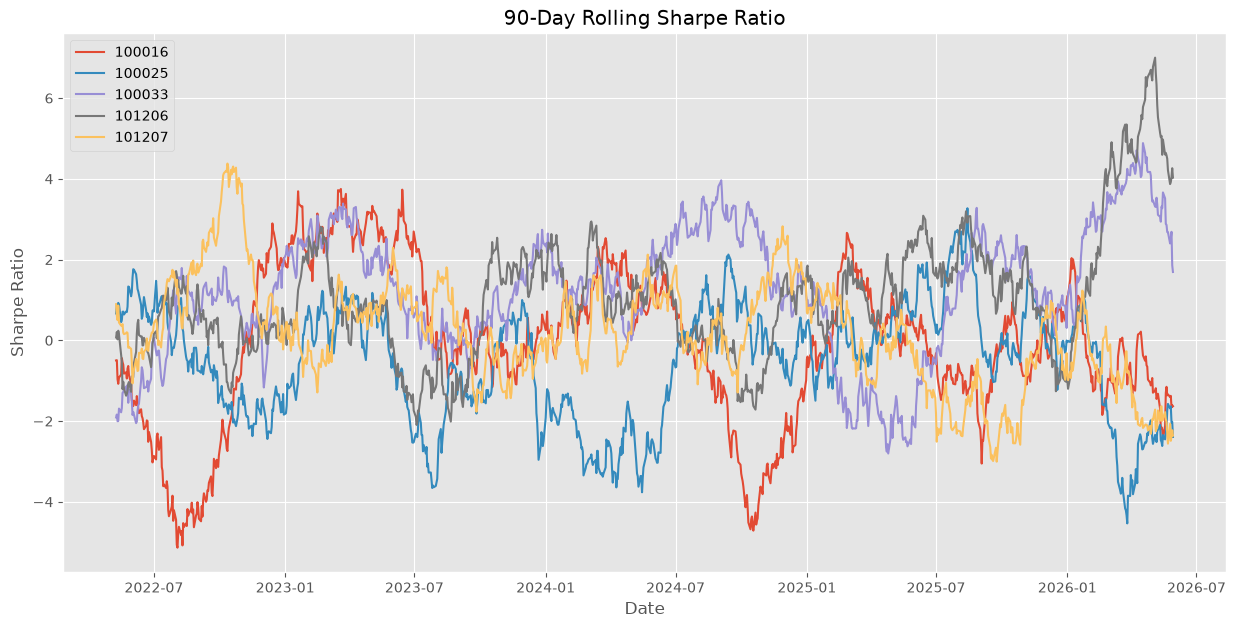

In [22]:
# Risk Free Rate (6.5%)

risk_free = 0.065

# Select 5 funds

top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(15,7))

# Loop through each fund

for fund in top5:

    temp = returns[returns["amfi_code"] == fund].copy()

    temp = temp.sort_values("date")

    # Calculate rolling Sharpe

    temp["rolling_sharpe"] = (
        (temp["daily_return"].rolling(90).mean() - risk_free/252)
        /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.show()

In [23]:
# Save chart

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.close()

# Task 3

## Investor Cohort Analysis

In [24]:
# Extract first transaction year

transactions["year"] = transactions["transaction_date"].dt.year

# First transaction year

transactions["cohort"] = transactions.groupby(
    "investor_id"
)["year"].transform("min")

In [25]:
cohort = transactions.groupby("cohort").agg(

    Average_SIP=("amount_inr","mean"),

    Total_Investment=("amount_inr","sum"),

    Total_Investors=("investor_id","nunique")

)

cohort

,Average_SIP,Total_Investment,Total_Investors
cohort,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [26]:
favorite = transactions.groupby(

    ["cohort","amfi_code"]

).size().reset_index(name="count")

favorite

,cohort,amfi_code,count
0,2024,100016,830
1,2024,100025,791
2,2024,100033,781
3,2024,101206,803
4,2024,101207,844
...,...,...,...
75,2025,148568,9
76,2025,148569,6
77,2025,149322,5
78,2025,149323,8


In [27]:
cohort.to_csv(

    "../reports/cohort_analysis.csv"

)

# Task 4

## SIP Continuity Analysis

In [28]:
# Keep only SIP transactions

sip = transactions[
    transactions["transaction_type"]=="SIP"
].copy()

sip = sip.sort_values(

    ["investor_id","transaction_date"]

)

In [29]:
sip["gap"] = sip.groupby(

    "investor_id"

)["transaction_date"].diff().dt.days

In [30]:
continuity = sip.groupby("investor_id").agg(

    Avg_Gap=("gap","mean"),

    SIP_Count=("gap","count")

)

continuity.head()

,Avg_Gap,SIP_Count
investor_id,,
INV000001,76.0,1
INV000002,207.0,2
INV000003,238.0,1
INV000004,85.4,5
INV000005,14.0,2


In [31]:
continuity["Status"] = np.where(

    continuity["Avg_Gap"]>35,

    "At Risk",

    "Healthy"

)

continuity.head()

,Avg_Gap,SIP_Count,Status
investor_id,,,
INV000001,76.0,1,At Risk
INV000002,207.0,2,At Risk
INV000003,238.0,1,At Risk
INV000004,85.4,5,At Risk
INV000005,14.0,2,Healthy


In [32]:
continuity.to_csv(

    "../reports/sip_continuity.csv"

)

# Task 5

## Fund Recommendation System

A simple recommendation model was created using Python.

The user enters a preferred risk level.

The program filters funds having the same risk grade.

Funds are ranked using Sharpe Ratio.

The top 3 funds are displayed as recommendations.

### Python Script

The recommendation model is implemented separately in:

recommender.py

# Task 6

## Sector Concentration Analysis (HHI)

In [33]:
# Display first five rows

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [34]:
# Convert weight column into numeric

portfolio["weight_pct"] = pd.to_numeric(
    portfolio["weight_pct"],
    errors="coerce"
)

In [35]:
# Remove missing weights

portfolio = portfolio.dropna(
    subset=["weight_pct"]
)

In [36]:
# Convert percentage into decimal

portfolio["weight_decimal"] = (
    portfolio["weight_pct"] / 100
)

# Square the weights

portfolio["weight_sq"] = (
    portfolio["weight_decimal"] ** 2
)

In [37]:
# Calculate HHI for every fund

hhi = portfolio.groupby(
    "amfi_code"
)["weight_sq"].sum().reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [38]:
# Merge with fund names

hhi = hhi.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [39]:
# Highest concentration

hhi = hhi.sort_values(

    by="HHI",

    ascending=False

)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


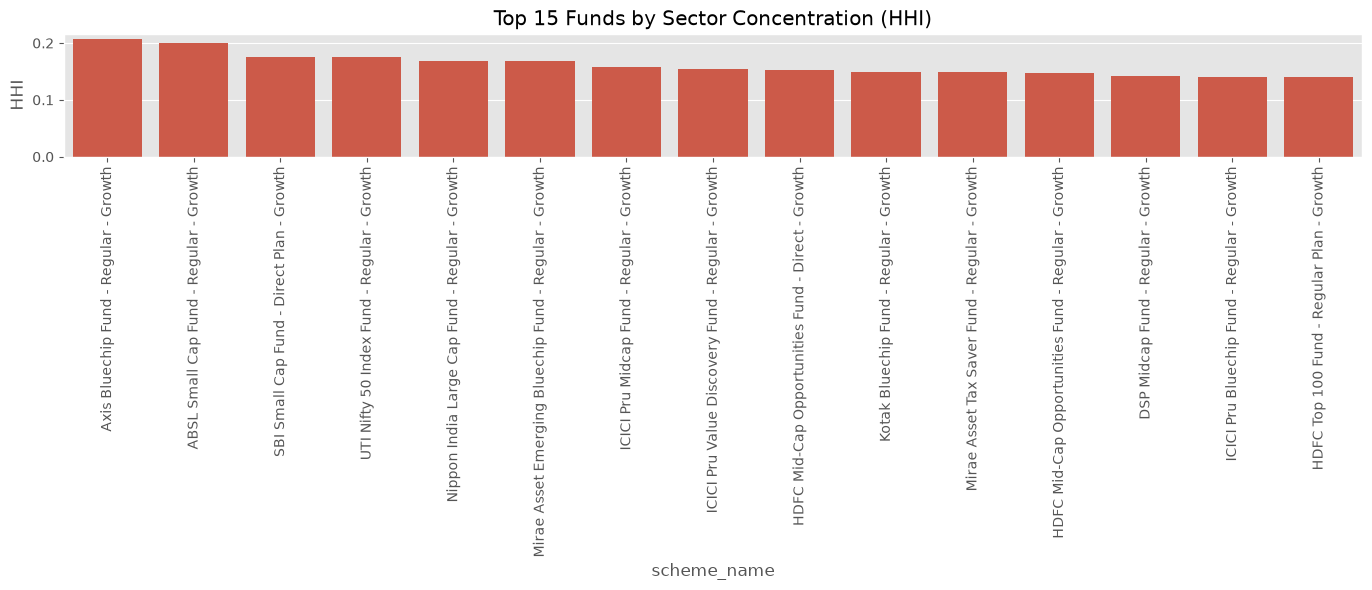

In [40]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=hhi.head(15),

    x="scheme_name",

    y="HHI"

)

plt.xticks(rotation=90)

plt.title("Top 15 Funds by Sector Concentration (HHI)")

plt.tight_layout()

plt.show()

In [41]:
plt.savefig(
    "../reports/sector_hhi_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [42]:
hhi.to_csv(

    "../reports/sector_hhi.csv",

    index=False

)

# Task 7

## Advanced Analytics Summary

### Insight 1

Funds with the highest VaR indicate greater downside risk during volatile market periods.

---

### Insight 2

Rolling Sharpe Ratio shows that fund performance changes over time rather than remaining constant.

---

### Insight 3

Recent investor cohorts contributed the highest investment amounts, indicating increasing participation in mutual funds.

---

### Insight 4

Investors with average SIP gaps greater than 35 days were identified as "At Risk" and may require engagement strategies.

---

### Insight 5

Funds with higher HHI values have concentrated sector exposure, while lower HHI values indicate better portfolio diversification.